In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import numpy as np
from sklearn.model_selection import GridSearchCV

In [2]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/top40_cell_cycle.csv")

#df['phase'] = df['phase'].replace({'M': 'G2'})

# Separate features and target
X = df.drop(columns=['phase', 'age'])  # exclude phase and age
y = df['age']  # target is now age

In [3]:
# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949)

# Train Random Forest Regressor with 500 trees and max depth 15
rf = RandomForestRegressor(n_estimators=500, max_depth=50, max_features='sqrt', random_state=949)


In [ ]:
## hypertuning

param_grid = {
    'n_estimators': [700, 800, 900]
    #'max_depth': [50, 60]         
}

# Set up GridSearch with 10-fold cross-validation optimizing for accuracy
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=10,
    scoring= 'neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit the model to your data
grid_search.fit(X_train, y_train)

#Output best settings and best accuracy
print("Best parameters:", grid_search.best_params_)


Best parameters: {'n_estimators': 700}


In [7]:
# OOB error 
# Define the values of max_features to test
max_features_options = [20, 25]  # Try 3–5 reasonable values

oob_results = {}

# Loop over different max_features
for mf in max_features_options:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=50,
        max_features=mf,
        oob_score=True,
        bootstrap=True,
        random_state=949,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    oob_results[mf] = root_mean_squared_error(y_train, rf.oob_prediction_)

# Show OOB results
print("=== OOB Scores by max_features ===")
for mf, score in oob_results.items():
    print(f"max_features={mf}: OOB Accuracy = {score:.4f}")

# Choose best setting
best_mf = max(oob_results, key=oob_results.get)
print(f"\nBest max_features based on OOB: {best_mf}")

=== OOB Scores by max_features ===
max_features=20: OOB Accuracy = 1.2115
max_features=25: OOB Accuracy = 1.2015

Best max_features based on OOB: 20


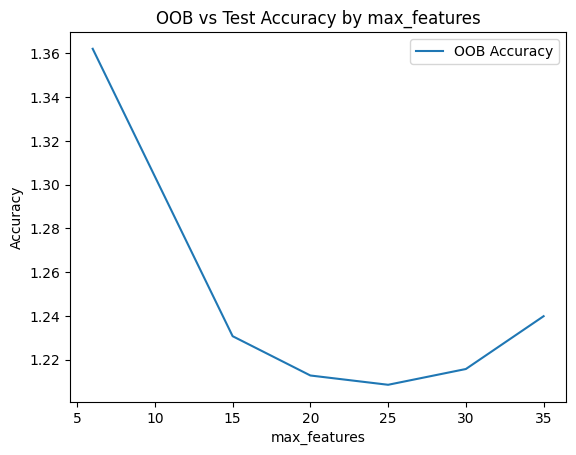

In [ ]:
## OOB plot
max_features_range = [6,15,20,25,30, 35]
oob_scores = []

for mf in max_features_range:
    rf = RandomForestRegressor(
        n_estimators=600,
        max_depth=50,
        max_features=mf,
        oob_score=True,
        random_state=42,
        bootstrap=True
    )
    rf.fit(X_train, y_train)
    
    oob_scores.append(root_mean_squared_error(y_train, rf.oob_prediction_))

plt.plot(max_features_range, oob_scores, label="OOB Accuracy")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("OOB vs Test Accuracy by max_features")
plt.legend()
plt.show()

In [4]:
#retrain
rf = RandomForestRegressor(n_estimators=700, max_depth=50, max_features=25, random_state=949)

rf.fit(X_train, y_train)

# Predict on training and test sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [5]:
# Calculate RMSE
rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print("=== Training Set ===")
print(f"RMSE: {rmse_train:.4f}")

print("\n=== Test Set ===")
print(f"RMSE: {rmse_test:.4f}")


# For training set
df_train = pd.DataFrame({
    'true_age': y_train,
    'pred_age': y_train_pred,
    'phase': df.loc[y_train.index, 'phase']  # get phase for train samples
})

rmse_per_phase_train = df_train.groupby('phase').apply(
    lambda x: np.sqrt(mean_squared_error(x['true_age'], x['pred_age']))
)

print("RMSE per phase (Train):")
print(rmse_per_phase_train)

# For test set
df_test = pd.DataFrame({
    'true_age': y_test,
    'pred_age': y_test_pred,
    'phase': df.loc[y_test.index, 'phase']  # get phase for test samples
})

rmse_per_phase_test = df_test.groupby('phase').apply(
    lambda x: np.sqrt(mean_squared_error(x['true_age'], x['pred_age']))
)

print("\nRMSE per phase (Test):")
print(rmse_per_phase_test)


=== Training Set ===
RMSE: 0.4432

=== Test Set ===
RMSE: 1.2911
RMSE per phase (Train):
phase
G0    0.455612
G1    0.370990
G2    0.431786
M     1.517580
S     0.474046
dtype: float64

RMSE per phase (Test):
phase
G0    1.398253
G1    1.071631
G2    1.392073
M     2.521155
S     1.372165
dtype: float64


/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_17828/1446578971.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_phase_train = df_train.groupby('phase').apply(
/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_17828/1446578971.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_per_phase_test = df_test.groupby('phase').apply(


In [7]:
# === Load existing results DataFrame ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/regression_results.csv", index_col=0)

# === Set values ===
model_name = "RF (top 40)"  # or whatever is appropriate
results_df.loc[model_name, 'Overall'] = rmse_test

# Fill in per-phase RMSEs
for phase in ['G0', 'G1', 'G2', 'M', 'S']:
    if phase in rmse_per_phase_test.index:
        results_df.loc[model_name, phase] = rmse_per_phase_test[phase]

# === Save updated results ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Bar Plot/regression_results.csv")

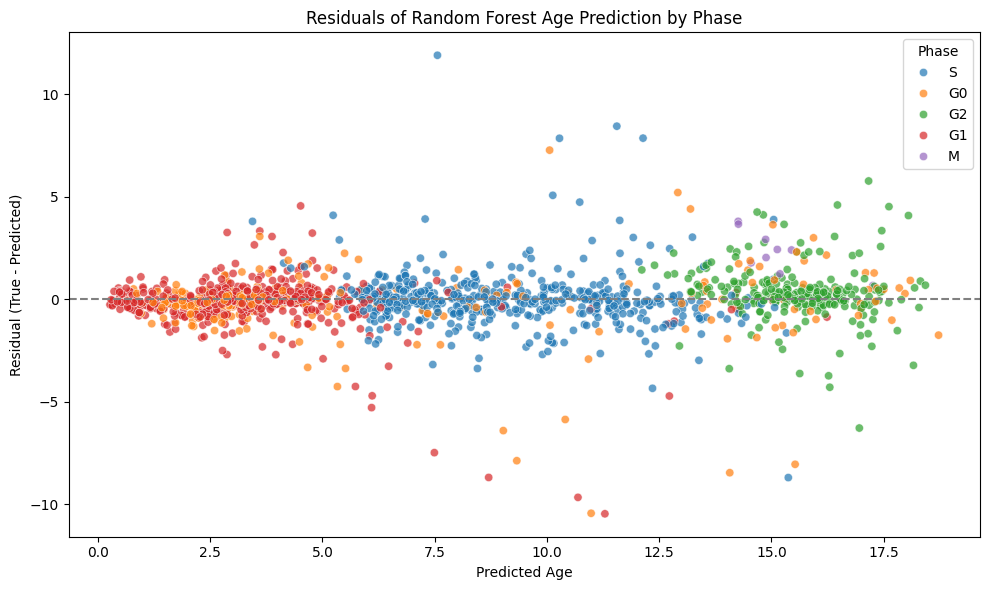

In [10]:
## PLOT RESIDUALS
# Create DataFrame for plotting
df_plot = pd.DataFrame({
    'True Age': y_test,
    'Predicted Age': y_test_pred,
    'Residual': y_test - y_test_pred,
    'Phase': df.loc[y_test.index, 'phase']
})

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='Predicted Age',
    y='Residual',
    hue='Phase',
    palette='tab10',
    alpha=0.7
)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Residuals of Random Forest Age Prediction by Phase")
plt.xlabel("Predicted Age")
plt.ylabel("Residual (True - Predicted)")
plt.legend(title='Phase')
plt.tight_layout()
# Save the plot
plot_path = "rf_regression_top40.png"
plt.savefig(plot_path, dpi=300)
plt.show()

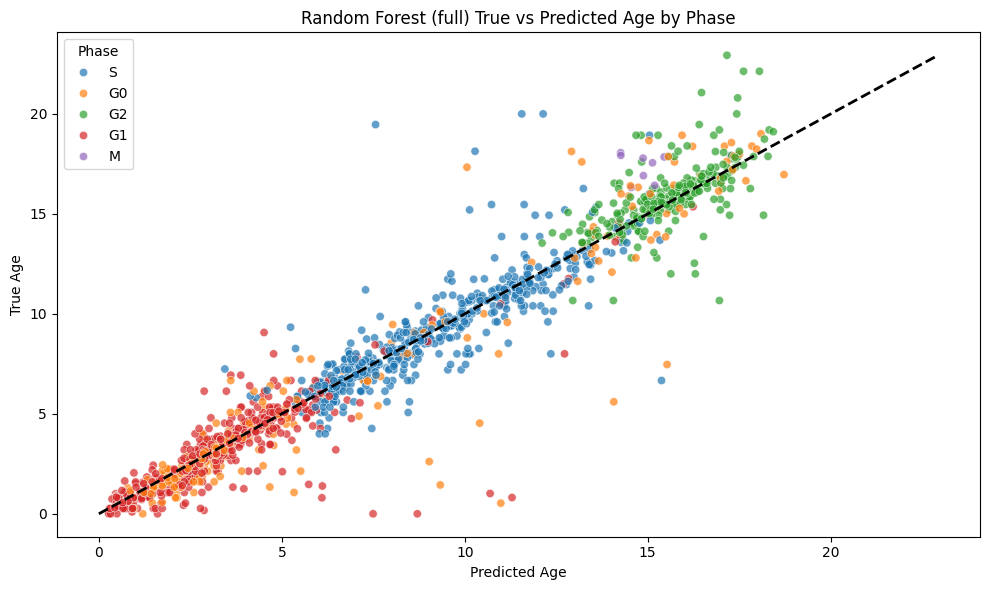

In [5]:
## Second residuals plot
# Create DataFrame for plotting
df_plot = pd.DataFrame({
    'True Age': y_test,
    'Predicted Age': y_test_pred,
    'Phase': df.loc[y_test.index, 'phase']
})

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='Predicted Age',
    y='True Age',
    hue='Phase',
    palette='tab10',
    alpha=0.7
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
#plt.axhline(0, color='gray', linestyle='--')
plt.title("Random Forest (full) True vs Predicted Age by Phase")
plt.xlabel("Predicted Age")
plt.ylabel("True Age")
plt.legend(title='Phase')
plt.tight_layout()

# Save the plot
#plot_path = "rf_regression_full.png"
#plt.savefig(plot_path, dpi=300)
plt.show()

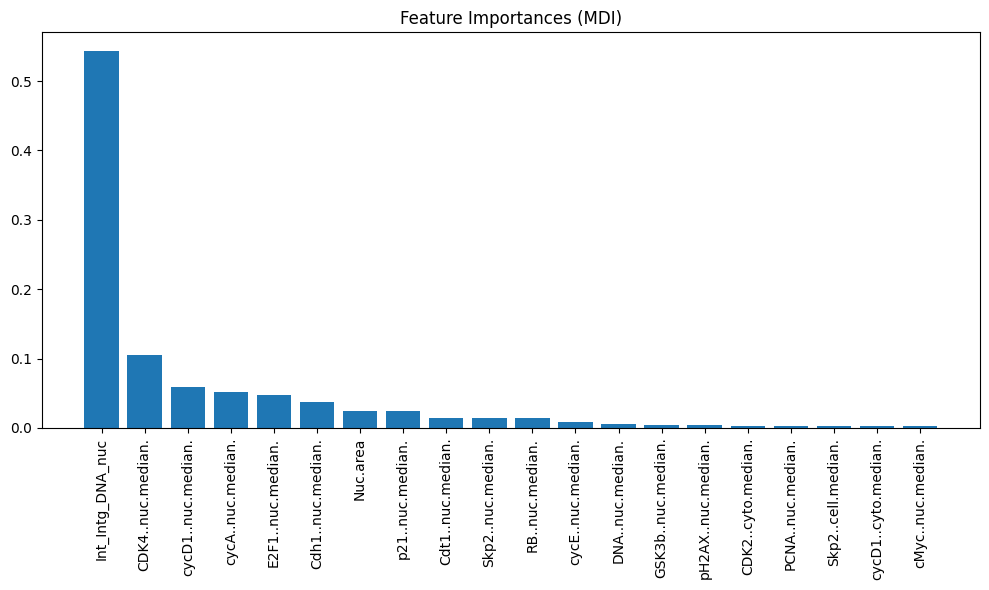

                Feature  MDI Importance
4      Int_Intg_DNA_nuc        0.543198
24    CDK4..nuc.median.        0.105659
2    cycD1..nuc.median.        0.058779
1     cycA..nuc.median.        0.051610
0     E2F1..nuc.median.        0.048070
8     Cdh1..nuc.median.        0.036785
7              Nuc.area        0.024062
3      p21..nuc.median.        0.023665
6     Cdt1..nuc.median.        0.014376
5     Skp2..nuc.median.        0.014354
13      RB..nuc.median.        0.014237
9     cycE..nuc.median.        0.009220
25     DNA..nuc.median.        0.004984
32   GSK3b..nuc.median.        0.004331
11   pH2AX..nuc.median.        0.003990
34   CDK2..cyto.median.        0.003393
10    PCNA..nuc.median.        0.002784
35   Skp2..cell.median.        0.002727
31  cycD1..cyto.median.        0.002629
12    cMyc..nuc.median.        0.002614
23    CDK2..nuc.median.        0.002536
15  cycB1..cyto.median.        0.002384
17   cycB1..nuc.median.        0.002333
27            Cell.area        0.002168


In [17]:
# Get feature importances (MDI)
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]  # Sort by importance descending

# Select top n indices
top_n = 20
top_indices = indices[:top_n]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (MDI)")
plt.bar(range(top_n), importances[top_indices], align='center')
plt.xticks(range(top_n), feature_names[top_indices], rotation=90)
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'MDI Importance': importances
}).sort_values(by='MDI Importance', ascending=False)

print(importance_df)

<Axes: title={'center': 'Random Forest MDI (Top 20)'}>

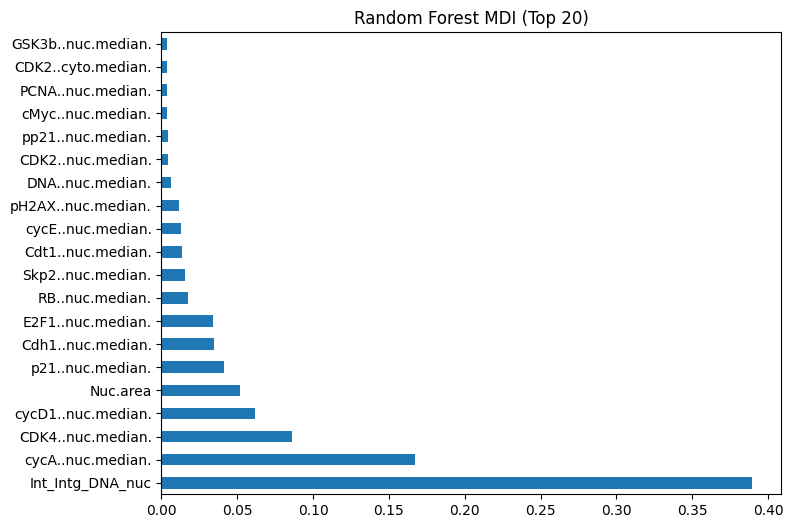

In [5]:
# Extract MDI importances
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

# Top features
rf_importances_sorted.head(20).plot(kind='barh', figsize=(8, 6), title='Random Forest MDI (Top 20)')